## **Comparação entre funções de Ativação em Feedforward Neural Network**

Vamos comparar os diferentes funções de ativação, a saber:

*   *Sigmoid*
*   *Tanh*
*   *ReLU*
*   *PReLU*
*   *GELU*

em uma Rede Neural *feedward* para tarefa de classificação no [**Covertype Dataset**](https://archive.ics.uci.edu/dataset/31/covertype).

#### **Função Sigmoid**

$$
\sigma(x) = \dfrac{1}{1 + \exp(-x)}
$$

Mapeia qualquer entrada real para o intervalo $(0, 1)$.

**Derivada:**

$$
\sigma'(x) = \sigma(x)\,(1 - \sigma(x))
$$

#### **Função Tanh**

$$
\tanh(x) = \dfrac{\exp(x) - \exp(-x)}{\exp(x) + \exp(-x)}
$$

Mapeia qualquer entrada real para o intervalo $(-1, 1)$, centrada em zero.

**Derivada:**

$$
\tanh'(x) = 1 - \tanh^2(x)
$$


#### **Função ReLU**

$$
\text{ReLU}(x) = (x)^+ = \max(0, x)
$$

Zera entradas negativas e mantém as positivas inalteradas.

**Derivada:**

$$
\text{ReLU}'(x) =
\begin{cases}
1, & \text{if } x > 0 \\
0, & \text{otherwise}
\end{cases}
$$

---

#### **Função PReLU**

$$
\text{PReLU}(x) =
\begin{cases}
x, & \text{if } x \geq 0 \\
ax, & \text{otherwise}
\end{cases}
$$

Generaliza a ReLU com inclinação $a$ aprendível para entradas negativas.

**Derivada:**

$$
\text{PReLU}'(x) =
\begin{cases}
1, & \text{if } x \geq 0 \\
a, & \text{otherwise}
\end{cases}
$$


#### **Função GELU**

$$
\text{GELU}(x) = x \cdot \Phi(x)
$$

onde $\Phi(x)$ é a CDF da distribuição normal padrão:

$$
\Phi(x) = P(X \leq x), \quad X \sim \mathcal{N}(0,1)
$$

Pondera cada entrada pela probabilidade de ser positiva sob uma normal.

**Derivada:**

$$
\text{GELU}'(x) = \Phi(x) + x\,\phi(x)
$$

onde $\phi(x) = \dfrac{1}{\sqrt{2\pi}}\exp\!\left(-\dfrac{x^2}{2}\right)$ é a PDF da normal padrão.

In [ ]:
!pip install ucimlrepo

### **Pré-processamento dos dados**

#### **Dataset**

In [ ]:
from ucimlrepo import fetch_ucirepo

covertype = fetch_ucirepo(id=31)

X, y = covertype.data.features, covertype.data.targets

In [ ]:
print(X.shape)

(581012, 54)


In [ ]:
print(y.shape)

(581012, 1)


#### **Dados de Treino e Dados de Teste**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

y_train = y_train - 1
y_test  = y_test - 1

In [ ]:
print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (464809, 54)
Teste: (116203, 54)


#### **Padronização dos dados**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

#### **Classe Dataset customizada**

In [ ]:
import torch
import torch.nn as nn

In [ ]:
from torch.utils.data import Dataset, DataLoader

class CovertypeDataset(Dataset):
  def __init__(self, X, y):
    self.X = torch.tensor(X, dtype=torch.float32)
    self.y = torch.tensor(y.values, dtype=torch.long).squeeze()

  def __len__(self):
    return len(self.y)

  def __getitem__(self, idx):
    return self.X[idx], self.y[idx]


train_dataset = CovertypeDataset(X_train, y_train)
test_dataset = CovertypeDataset(X_test, y_test)

#### **DataLoaders**

In [ ]:
batch_size = 256

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size
)

for X_batch, y_batch in train_loader:
    print(X_batch.shape)
    print(y_batch.shape)
    break

torch.Size([256, 54])
torch.Size([256])


### **Construção do Modelo**

#### **Fixando parâmetros**

In [ ]:
DEVICE = (
    torch.accelerator.current_accelerator().type
    if torch.accelerator.is_available()
    else "cpu"
)
LR      = 1e-3
EPOCHS  = 100
LOSS_FN = nn.CrossEntropyLoss()

In [ ]:
class CovertypeNet(nn.Module):
  def __init__(self, activationFunction):
    super().__init__()
    self.network = nn.Sequential(
      nn.Linear(54, 128),
      activationFunction(),
      nn.Dropout(0.3),
      nn.Linear(128, 256),
      activationFunction(),
      nn.Dropout(0.3),
      nn.Linear(256, 128),
      activationFunction(),
      nn.Linear(128, 7)
    )

  def forward(self, x):
    return self.network(x)

O modelo foi definido com a seguinte sequência de camadas:

$$
\text{model} = \text{Sequential}\bigl(
    \underbrace{\text{Linear}(54,128)}_{\mathbf{W}^{(1)} \in \mathbb{R}^{128\times54},\; \mathbf{b}^{(1)} \in \mathbb{R}^{128}},\,
    h(\cdot),
    \underbrace{\text{Linear}(128,256)}_{\mathbf{W}^{(2)} \in \mathbb{R}^{256\times128},\; \mathbf{b}^{(2)} \in \mathbb{R}^{256}},\,
    h(\cdot),
    \underbrace{\text{Linear}(256,128)}_{\mathbf{W}^{(3)} \in \mathbb{R}^{128\times256},\; \mathbf{b}^{(3)} \in \mathbb{R}^{128}},\,
    h(\cdot),
    \underbrace{\text{Linear}(128,7)}_{\mathbf{W}^{(4)} \in \mathbb{R}^{7\times128},\; \mathbf{b}^{(4)} \in \mathbb{R}^{7}}
\bigr)
$$

Cada camada $\text{Linear}$ computa:

$$
\mathbf{a}^{(\ell)} = \mathbf{W}^{(\ell)}\mathbf{z}^{(\ell-1)} + \mathbf{b}^{(\ell)}
$$

e a função de ativação $h(\cdot)$ é aplicada elemento a elemento:

$$
\mathbf{z}^{(\ell)} = h\!\left(\mathbf{a}^{(\ell)}\right)
$$

### **Função de Treino**

In [ ]:
def train_epoch(dataloader, model, loss_fn, optimizer):
  model.train()
  total_loss = 0

  for X, y in dataloader:
    X, y = X.to(DEVICE), y.to(DEVICE)

    optimizer.zero_grad()
    pred = model(X)
    loss = loss_fn(pred, y)
    loss.backward()
    optimizer.step()

    total_loss += loss.item()

  return total_loss / len(dataloader)

### **Função de Avaliação**

In [ ]:
def eval_epoch(loader, model, loss_fn):
  model.eval()
  total_loss = 0

  with torch.no_grad():
    for X, y in loader:
      X, y = X.to(DEVICE), y.to(DEVICE)
      pred = model(X)
      total_loss += loss_fn(pred, y).item()

  n = len(loader.dataset)
  loss = total_loss/len(loader)

  return loss

#### **Loop de Epochs para cada Função de Ativação**

In [ ]:
ACTIVATEFUNCTIONS = {
    "Sigmoid": nn.Sigmoid,
    "Tanh":    nn.Tanh,
    "ReLU":    nn.ReLU,
    "GELU":    nn.GELU,
    "PReLU":   nn.PReLU,
}

In [ ]:
import gc

history = {}

for name, act_fn in ACTIVATEFUNCTIONS.items():

  model = CovertypeNet(act_fn).to(DEVICE)

  OPTIMIZER = torch.optim.Adam(
    model.parameters(), lr=LR
  )

  hist = {"train_loss": [], "val_loss": []}
  train_losses = []
  test_losses  = []

  print(f"Model Train with: {name}")

  for t in range(EPOCHS):
      train_loss = train_epoch(train_loader, model, LOSS_FN, OPTIMIZER)
      val_loss  = eval_epoch(test_loader, model, LOSS_FN)

      hist["train_loss"].append(train_loss)
      hist["val_loss"].append(val_loss)

      if (t + 1) % 10 == 0:
          print(f"Epoch {t+1:3d}/{EPOCHS} | train: {train_loss:.4f} | test: {val_loss:.4f}")

  print("Done!\n")

  history[name] = hist

  del model, OPTIMIZER
  gc.collect()
  if DEVICE == "cuda":
      torch.cuda.empty_cache()

Model Train with: Sigmoid
Epoch  10/100 | train: 0.4999 | test: 0.4474
Epoch  20/100 | train: 0.4302 | test: 0.3614
Epoch  30/100 | train: 0.3973 | test: 0.3197
Epoch  40/100 | train: 0.3763 | test: 0.2940
Epoch  50/100 | train: 0.3640 | test: 0.2765
Epoch  60/100 | train: 0.3538 | test: 0.2638
Epoch  70/100 | train: 0.3456 | test: 0.2570
Epoch  80/100 | train: 0.3395 | test: 0.2485
Epoch  90/100 | train: 0.3354 | test: 0.2415
Epoch 100/100 | train: 0.3306 | test: 0.2394
Done!

Model Train with: Tanh
Epoch  10/100 | train: 0.3962 | test: 0.3099
Epoch  20/100 | train: 0.3715 | test: 0.2757
Epoch  30/100 | train: 0.3606 | test: 0.2654
Epoch  40/100 | train: 0.3552 | test: 0.2558
Epoch  50/100 | train: 0.3508 | test: 0.2524
Epoch  60/100 | train: 0.3490 | test: 0.2498
Epoch  70/100 | train: 0.3454 | test: 0.2447
Epoch  80/100 | train: 0.3446 | test: 0.2461
Epoch  90/100 | train: 0.3424 | test: 0.2412
Epoch 100/100 | train: 0.3397 | test: 0.2407
Done!

Model Train with: ReLU
Epoch  10/100 

### **Curva de Loss para cada Otimizador**

In [ ]:
import matplotlib.pyplot as plt

#### **Sigmoid**


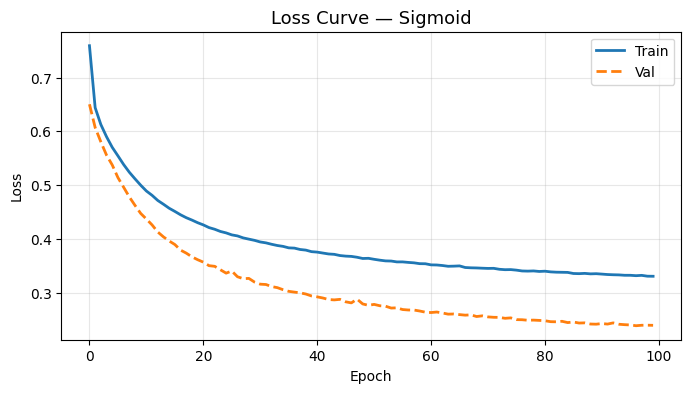

In [ ]:
name = "Sigmoid"
hist = history[name]

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(hist["train_loss"], label="Train", linewidth=2)
ax.plot(hist["val_loss"],   label="Val", linewidth=2, linestyle="--")

ax.set_title(f"Loss Curve — {name}", fontsize=13)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.grid(True, alpha=0.3)
ax.legend()

plt.show()

#### **Tanh**

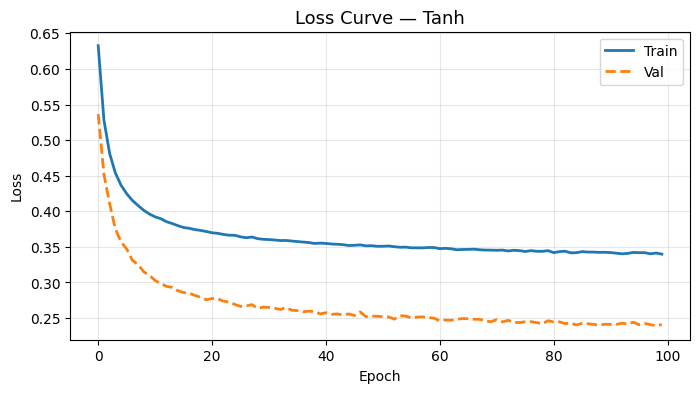

In [ ]:
name = "Tanh"
hist = history[name]

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(hist["train_loss"], label="Train", linewidth=2)
ax.plot(hist["val_loss"],   label="Val", linewidth=2, linestyle="--")

ax.set_title(f"Loss Curve — {name}", fontsize=13)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.grid(True, alpha=0.3)
ax.legend()

plt.show()

#### **ReLU**

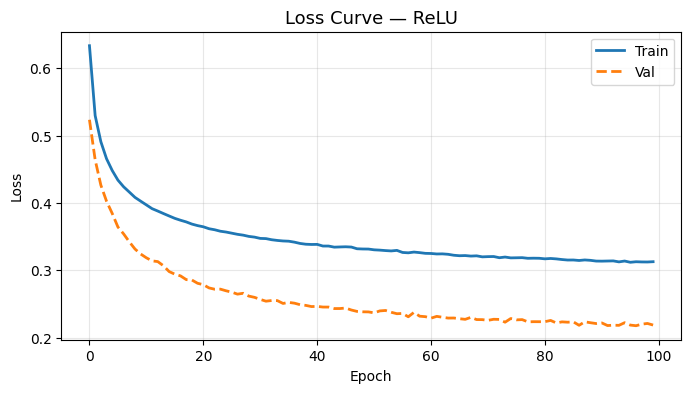

In [ ]:
name = "ReLU"
hist = history[name]

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(hist["train_loss"], label="Train", linewidth=2)
ax.plot(hist["val_loss"],   label="Val", linewidth=2, linestyle="--")

ax.set_title(f"Loss Curve — {name}", fontsize=13)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.grid(True, alpha=0.3)
ax.legend()

plt.show()

#### **GELU**

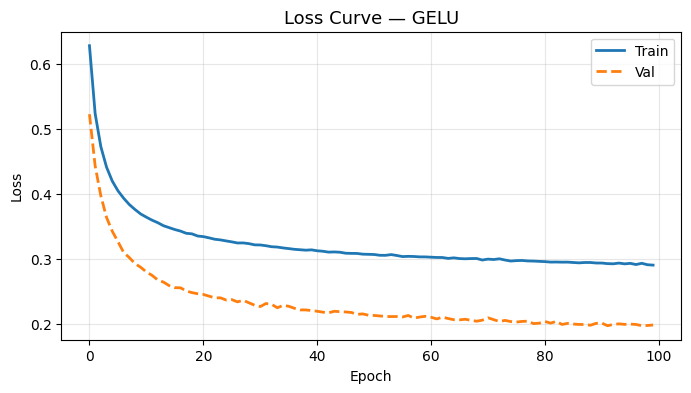

In [ ]:
name = "GELU"
hist = history[name]

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(hist["train_loss"], label="Train", linewidth=2)
ax.plot(hist["val_loss"],   label="Val", linewidth=2, linestyle="--")

ax.set_title(f"Loss Curve — {name}", fontsize=13)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.grid(True, alpha=0.3)
ax.legend()

plt.show()

### **Comparativo entre as Curvas de Loss no treino para cada Função de Ativação**

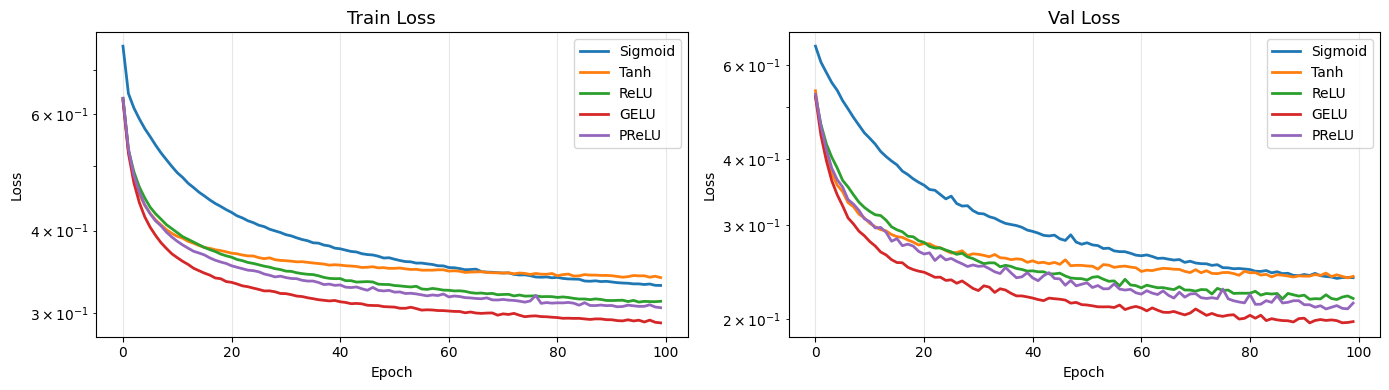

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for name, data in history.items():
    axes[0].plot(data["train_loss"], label=name, linewidth=2)
    axes[1].plot(data["val_loss"],   label=name, linewidth=2)

for ax, title in zip(axes, ["Train Loss", "Val Loss"]):
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_yscale("log")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()